In [6]:
from google.colab import files
uploaded = files.upload()

# After running this cell, a file picker will appear.
# Upload both:
#   - client_data (1).csv
#   - price_data (1).csv

Saving price_data (1).csv to price_data (1).csv
Saving client_data (1).csv to client_data (1) (1).csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Load the datasets
client_df = pd.read_csv('client_data (1).csv')
price_df  = pd.read_csv('price_data (1).csv')

print(f"Client data shape : {client_df.shape}")
print(f"Price data shape  : {price_df.shape}")

Client data shape : (14606, 26)
Price data shape  : (193002, 8)


In [9]:
print("CLIENT DATA – Data Types & Info")
print("="*50)
client_df.info()
print("\n\nPRICE DATA – Data Types & Info")
print("="*50)
price_df.info()

CLIENT DATA – Data Types & Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  

In [10]:
# Convert date columns
date_cols_client = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols_client:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

# Replace 'MISSING' with NaN in categorical columns
client_df['channel_sales'] = client_df['channel_sales'].replace('MISSING', np.nan)
client_df['origin_up']     = client_df['origin_up'].replace('MISSING', np.nan)

print("Dates converted & 'MISSING' cleaned")

Dates converted & 'MISSING' cleaned


In [11]:
print("CLIENT DATA – Numerical Summary")
display(client_df.describe())

print("\nCategorical columns – Top values")
cat_cols = ['channel_sales', 'has_gas', 'origin_up']
for col in cat_cols:
    print(f"\n{col.upper()}:")
    print(client_df[col].value_counts(dropna=False).head(10))

CLIENT DATA – Numerical Summary


,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912448,2016-07-27 20:48:26.422018560,2013-01-02 12:29:10.951663872,2015-07-21 06:59:00.353279488,1868.614880,1399.762906,0.966726,...,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,...,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,...,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,...,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,...,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,...,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175



Categorical columns – Top values

CHANNEL_SALES:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
NaN                                 3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

HAS_GAS:
has_gas
f    11955
t     2651
Name: count, dtype: int64

ORIGIN_UP:
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
NaN                                   64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64


In [12]:
churn_rate = client_df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(client_df['churn'].value_counts())

Overall Churn Rate: 9.72%
churn
0    13187
1     1419
Name: count, dtype: int64


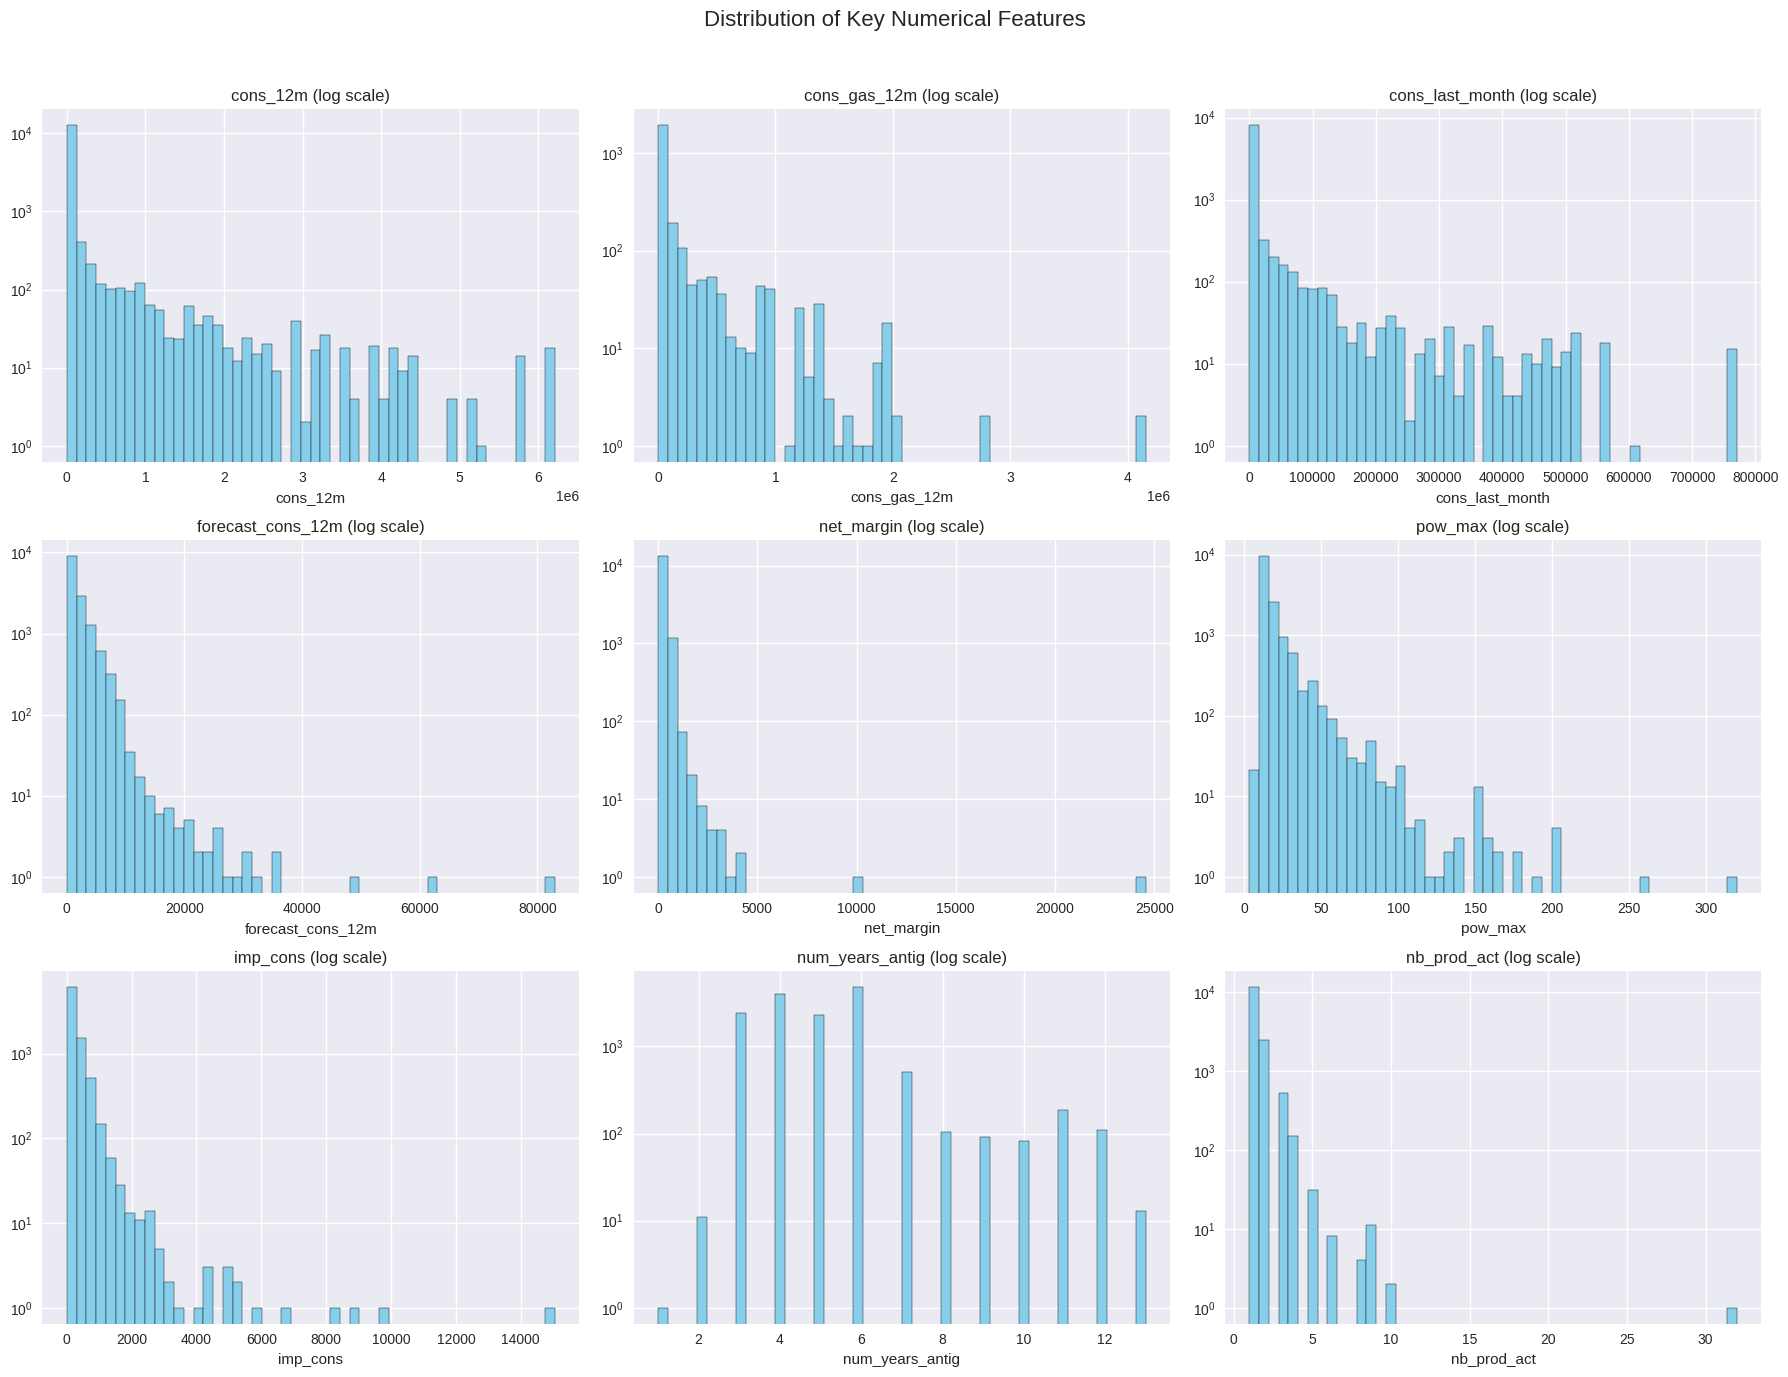

In [13]:
num_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month',
            'forecast_cons_12m', 'net_margin', 'pow_max', 'imp_cons',
            'num_years_antig', 'nb_prod_act']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    data = client_df[col]
    if data.max() > 1e6 or data.skew() > 1:
        axes[i].hist(data[data > 0], bins=50, log=True, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{col} (log scale)')
    else:
        axes[i].hist(data, bins=50, color='skyblue', edgecolor='black')
        axes[i].set_title(col)
    axes[i].set_xlabel(col)

plt.suptitle('Distribution of Key Numerical Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [14]:
print("PRICE DATA – Summary")
display(price_df.describe())

PRICE DATA – Summary


,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161216,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592


In [15]:
price_summary = price_df.groupby('id').agg({
    'price_off_peak_var' : 'mean',
    'price_peak_var'     : 'mean',
    'price_mid_peak_var' : 'mean',
    'price_off_peak_fix' : 'mean',
    'price_peak_fix'     : 'mean',
    'price_mid_peak_fix' : 'mean'
}).reset_index()

price_summary.columns = ['id', 'avg_off_peak_var', 'avg_peak_var', 'avg_mid_peak_var',
                         'avg_off_peak_fix', 'avg_peak_fix', 'avg_mid_peak_fix']

print(f"Average prices calculated for {price_summary.shape[0]:,} customers")

Average prices calculated for 16,096 customers


In [16]:
merged_df = client_df.merge(price_summary, on='id', how='left')
print(f"Merged dataset shape: {merged_df.shape}")

Merged dataset shape: (14606, 32)


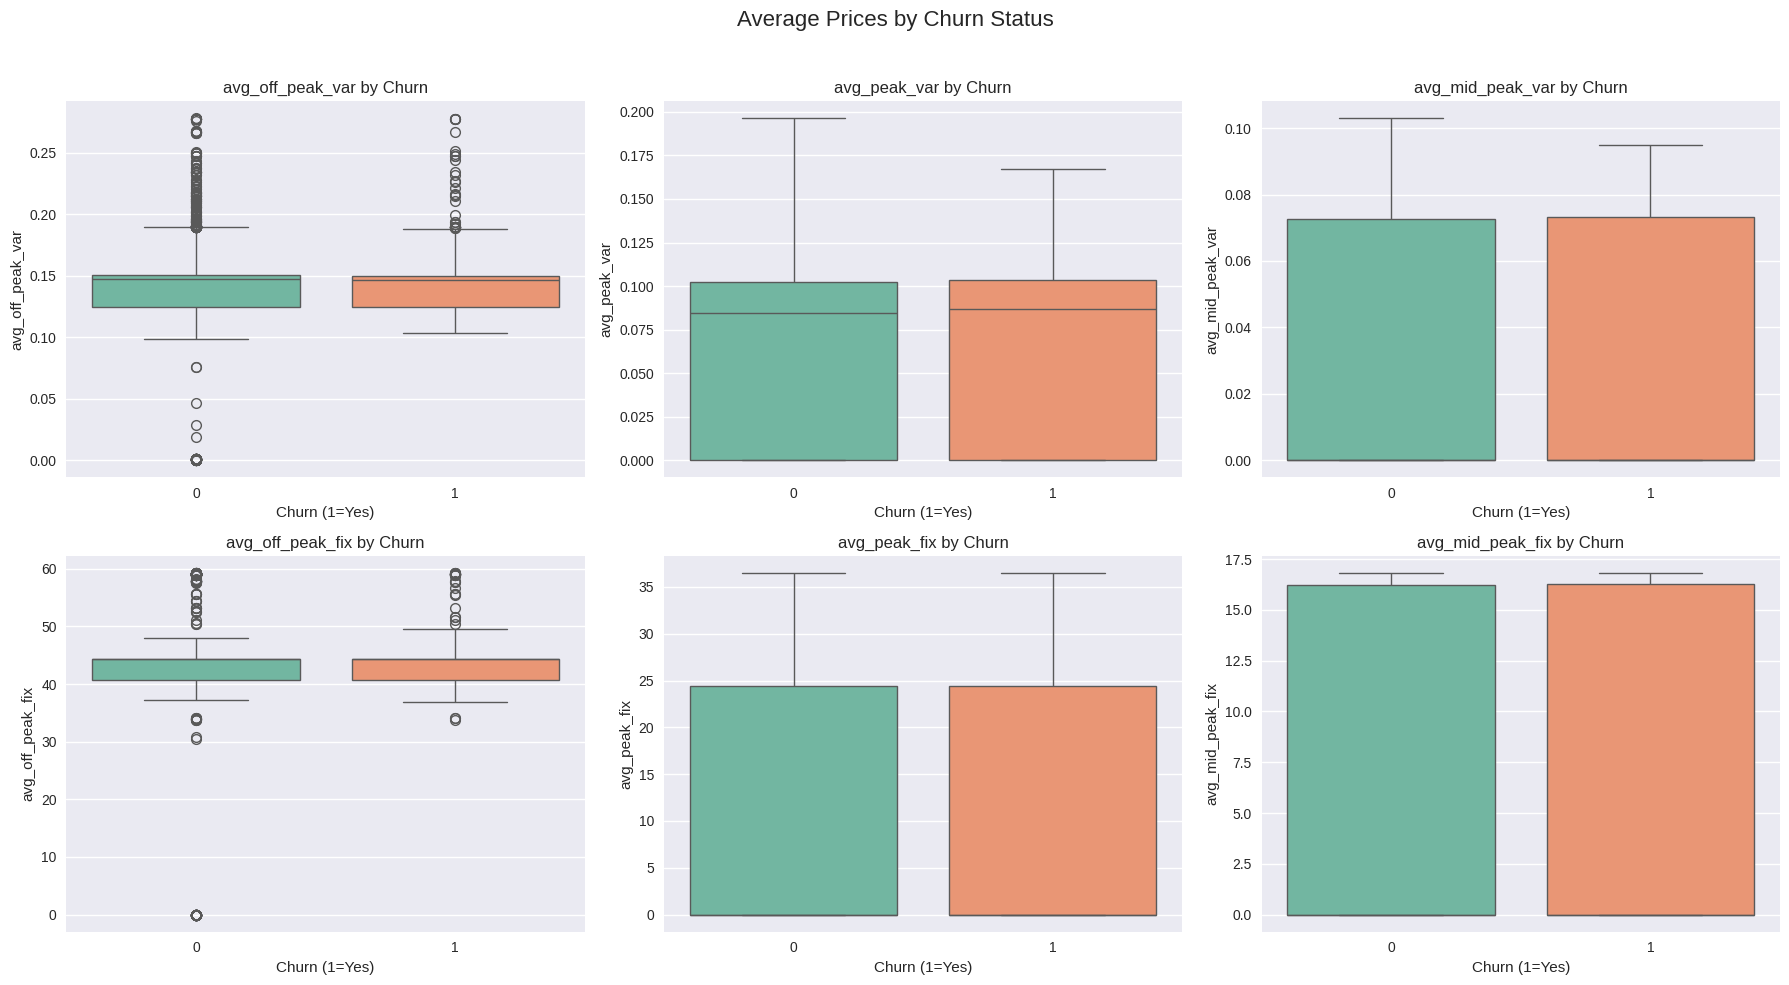

In [17]:
price_cols = ['avg_off_peak_var', 'avg_peak_var', 'avg_mid_peak_var',
              'avg_off_peak_fix', 'avg_peak_fix', 'avg_mid_peak_fix']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(price_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(data=merged_df, x='churn', y=col, ax=ax, palette="Set2")
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('Churn (1=Yes)')

plt.suptitle('Average Prices by Churn Status', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

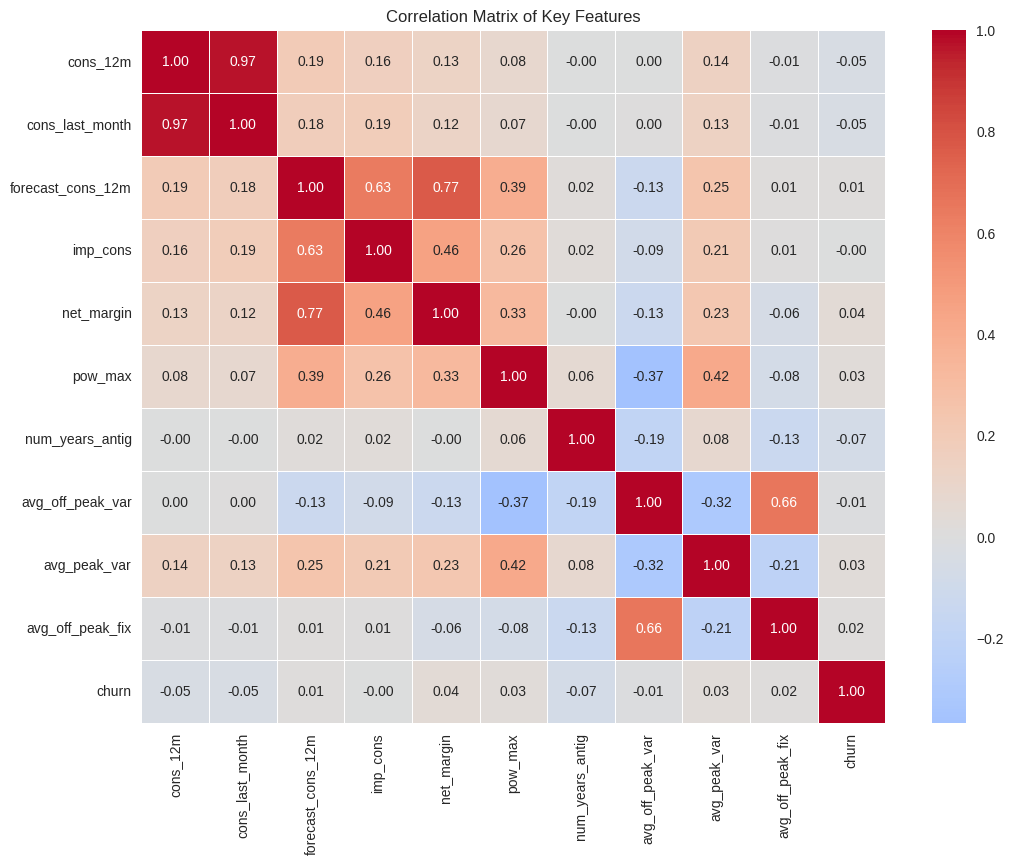

In [18]:
select_cols = ['cons_12m', 'cons_last_month', 'forecast_cons_12m', 'imp_cons',
               'net_margin', 'pow_max', 'num_years_antig',
               'avg_off_peak_var', 'avg_peak_var', 'avg_off_peak_fix', 'churn']

corr = merged_df[select_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Key Features')
plt.show()

In [19]:
print("KEY INSIGHTS FROM EDA")
print("="*60)
print(f"• Total customers          : {len(client_df):,}")
print(f"• Overall churn rate       : {churn_rate:.2f}% (highly imbalanced)")
print(f"• Electricity-only customers: {(client_df['has_gas'] == 'f').mean()*100:.1f}%")
print(f"• Avg tenure               : {client_df['num_years_antig'].mean():.1f} years")
print(f"• Consumption & margin are heavily right-skewed → use log transform in modeling")
print(f"• Many customers have zero peak/mid-peak prices → different tariff types")
print(f"• Prices changed multiple times in 2015 → price sensitivity features are valuable")
print(f"• Top sales channel        : {client_df['channel_sales'].value_counts().index[0]}")

KEY INSIGHTS FROM EDA
• Total customers          : 14,606
• Overall churn rate       : 9.72% (highly imbalanced)
• Electricity-only customers: 81.8%
• Avg tenure               : 5.0 years
• Consumption & margin are heavily right-skewed → use log transform in modeling
• Many customers have zero peak/mid-peak prices → different tariff types
• Prices changed multiple times in 2015 → price sensitivity features are valuable
• Top sales channel        : foosdfpfkusacimwkcsosbicdxkicaua


In [20]:
merged_df.to_csv('merged_client_price_data.csv', index=False)
files.download('merged_client_price_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>